# Teste de Baseline com regressão linear para predição de resistência à compressão

In [ ]:
%%capture
!pip install mapie catboost

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.compose import TransformedTargetRegressor
from mapie.regression import SplitConformalRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import RidgeCV
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão linear Ridge
ridge_file = 'df_resistencia_Ridge.pkl'
ridge_path = os.path.join(dirpath, ridge_file)

df_ridge = pd.read_pickle(ridge_path)
df_ridge['target'] = df_ridge['Resistencia_Compressao_MPa'].copy()
df_ridge.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

# Regressão neural
rna_file = 'df_resistencia_MLP.pkl'
rna_path = os.path.join(dirpath, rna_file)

df_rna = pd.read_pickle(rna_path)
df_rna['target'] = df_rna['Resistencia_Compressao_MPa'].copy()
df_rna.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

cat_file = 'df_resistencia_CatBoost.pkl'
cat_path = os.path.join(dirpath, cat_file)
df_cat = pd.read_pickle(cat_path)
df_cat['target'] = df_cat['Resistencia_Compressao_MPa'].copy()
df_cat.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

cols_rna = df_rna.drop(columns=['target', 'Autores/ano']).columns.tolist()
cols_cat = df_cat.drop(columns=['target', 'Autores/ano']).columns.tolist()
cols_ridge = df_ridge.columns.tolist()

# 1. Concatena os DataFrames lado a lado
df_final = pd.concat([df_ridge[cols_ridge], df_rna[cols_rna], df_cat[cols_cat]], axis=1)

# 2. Remove colunas com nomes duplicados (mantém apenas a primeira ocorrência, que vem do Ridge)
df_final = df_final.loc[:, ~df_final.columns.duplicated()].copy()

# 3. Remove os NaNs gerados por possível desalinhamento de índices
df_final.dropna(inplace=True)

# Verifica o formato final
print(df_final.shape)

(511, 21)


In [ ]:
n_groups = df_ridge['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [ ]:
best_params_rna = {
    'hidden_layer_sizes': (88, 12),
    'activation': "identity",
    'solver': "adam",
    'alpha': 3.9009722610862565,
    'max_iter': 6850,
    'n_iter_no_change': 10,
    'early_stopping': True,
    'random_state': 42
}

In [ ]:
best_params_catboost = {
    'iterations': 1762,
    'learning_rate': 0.05415258602295866,
    'depth': 2,
    'l2_leaf_reg': 96.66483854714893,
    'min_data_in_leaf': 7,
    'random_strength': 2.5251538918697816,
    'bagging_temperature': 5.095582164986734,
    'rsm': 0.7607689119415048,
    'od_wait': 35,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'od_type': 'Iter',
    'verbose': 0

}

In [ ]:
best_params_ridge = {
    'alpha': 0.4560659093031946,
    'random_state': 42
}

In [ ]:
all_instances = []

X = df_final.drop(columns=["target", "Autores/ano"])
y = df_final["target"]
groups = df_final["Autores/ano"]

for fold, (train_idx, val_idx) in tqdm(enumerate(gkf.split(X, y, groups)), total=gkf.get_n_splits(X, y, groups), desc="Folds", unit="fold"):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]
    groups_train = groups.iloc[train_idx]

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    fit_idx, calib_idx = next(gss.split(X_train, y_train, groups_train))

    X_train_fit = X_train.iloc[fit_idx]
    X_calib = X_train.iloc[calib_idx]
    y_train_fit = y_train.iloc[fit_idx]
    y_calib = y_train.iloc[calib_idx]

    # ---------------------------------------------------------
    # 1. ESCALONAMENTO (Preservando o formato Pandas)
    # ---------------------------------------------------------
    # O set_output("pandas") garante que os nomes das colunas sobrevivam ao scaler
    scaler = StandardScaler().set_output(transform="pandas")

    X_train_fit = scaler.fit_transform(X_train_fit)
    X_calib = scaler.transform(X_calib)
    X_val = scaler.transform(X_val)

    # ---------------------------------------------------------
    # 2. FILTRAGEM DE FEATURES
    # ---------------------------------------------------------
    idx_rna = [X_train_fit.columns.get_loc(c) for c in cols_rna]
    idx_cat = [X_train_fit.columns.get_loc(c) for c in cols_cat]

    filtro_rna = ColumnTransformer(
        transformers=[('selector', 'passthrough', idx_rna)],
        remainder='drop'
    )

    filtro_cat = ColumnTransformer(
        transformers=[('selector', 'passthrough', idx_cat)],
        remainder='drop'
    )

    # ---------------------------------------------------------
    # 3. INSTANCIAÇÃO DO SUPERMODELO
    # ---------------------------------------------------------
    base_estimators = [
        ('rna_pipeline', Pipeline([
            ('filtro', filtro_rna),
            ('modelo', MLPRegressor(**best_params_rna))
        ])),
        ('cat_pipeline', Pipeline([
            ('filtro', filtro_cat),
            ('modelo', CatBoostRegressor(**best_params_catboost))
        ]))
    ]

    alpha_ridge = np.logspace(-3, 2, 100)

    meta_estimator = RidgeCV(alphas=alpha_ridge, cv=5)

    stacking_regressor = StackingRegressor(
        estimators=base_estimators,
        final_estimator=meta_estimator,
        passthrough=True,
        cv=5,
        n_jobs=-1
    )

    super_modelo = TransformedTargetRegressor(
        regressor=stacking_regressor,
        func=np.log1p,
        inverse_func=np.expm1
    )

    # ---------------------------------------------------------
    # 4. TREINAMENTO E CONFORMAL PREDICTION
    # ---------------------------------------------------------
    super_modelo.fit(X_train_fit, y_train_fit)

    conformal = SplitConformalRegressor(
        estimator=super_modelo,
        confidence_level=0.90,
        prefit=True
    )

    conformal.conformalize(X_calib, y_calib)

    preds, intervals = conformal.predict_interval(X_val)

    lower = intervals[:, 0, 0]
    upper = intervals[:, 1, 0]

    fold_results = df_final.iloc[val_idx].copy()
    fold_results["y_true"] = y_val.values
    fold_results["y_pred"] = preds
    fold_results["error"] = fold_results["y_true"] - fold_results["y_pred"]
    fold_results["abs_error"] = fold_results["error"].abs()
    fold_results["lower"] = lower
    fold_results["upper"] = upper
    fold_results["covered"] = (fold_results["y_true"] >= lower) & (fold_results["y_true"] <= upper)
    fold_results["group"] = groups.iloc[val_idx].values

    all_instances.append(fold_results)

Folds:   0%|          | 0/17 [00:00<?, ?fold/s]

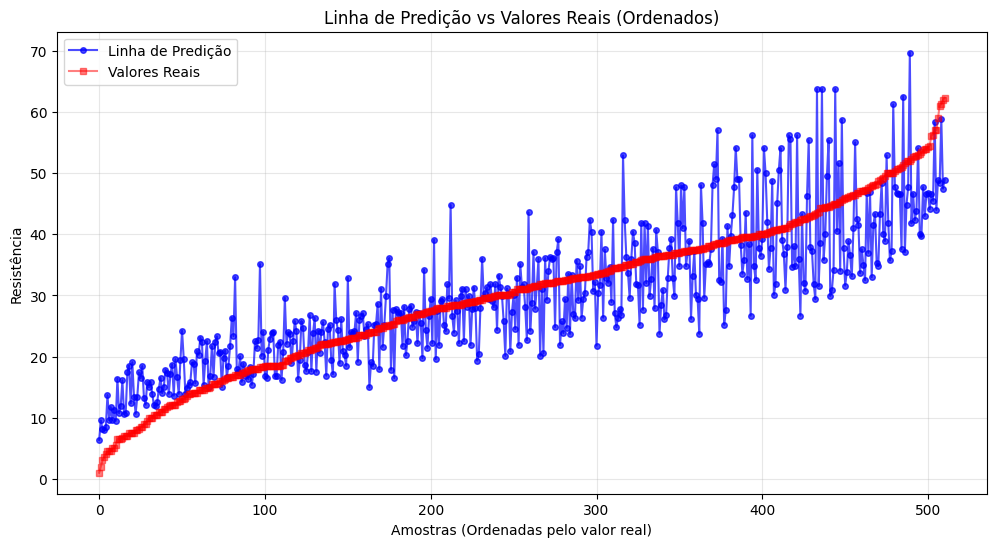

In [ ]:
ridge_results = pd.concat(all_instances, ignore_index=True)

# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = ridge_results.sort_values(by="y_true")
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:

coverage = (ridge_results["covered"].mean())

print("Coverage:", coverage)

ridge_results['interval_width'] = (
    ridge_results['upper'] - ridge_results['lower']
)

ridge_results['error'] = (
    ridge_results['y_true'] - ridge_results['y_pred']
)

ridge_results['abs_error'] = (
    ridge_results['error'].abs()
)

ridge_results["residual"] = (
    ridge_results["y_true"] -
    ridge_results["y_pred"]
)

ridge_results["abs_error"] = (
    ridge_results["residual"].abs()
)

Coverage: 0.9099804305283757


In [ ]:
below = (
    ridge_results["y_true"] < ridge_results["lower"]
).mean()

above = (
    ridge_results["y_true"] > ridge_results["upper"]
).mean()

print("Below:", below)
print("Above:", above)

print(
    "MAE:",
    ridge_results["abs_error"].mean()
)

print(
    "Mean interval width:",
    ridge_results["interval_width"].mean()
)

relative_width = (
    (ridge_results["upper"] - ridge_results["lower"]).mean()
    / ridge_results["y_true"].std()
)

print(f"Relative width: {relative_width}")

Below: 0.03913894324853229
Above: 0.050880626223091974
MAE: 5.6305036690494275
Mean interval width: 26.23124295088259
Relative width: 2.072746308551363


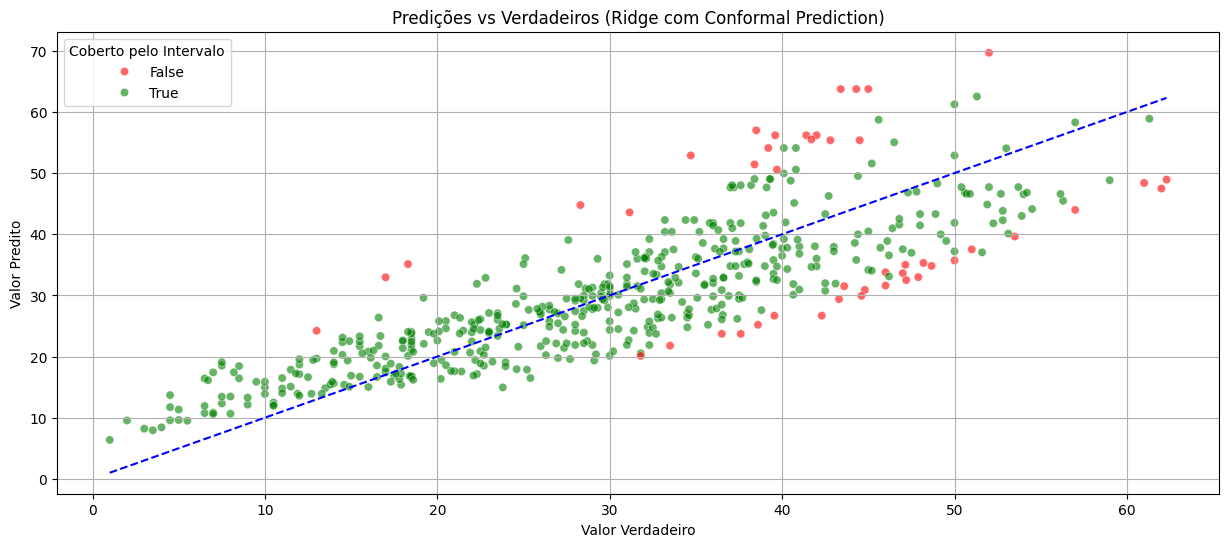

In [ ]:
fold_summary = (
    ridge_results
    .groupby("group")
    .agg(
        coverage=("covered", "mean"),
        width=("interval_width", "mean"),
        mae=("abs_error", "mean")
    )
)

plt.figure(figsize=(15, 6))
sns.scatterplot(
    data=ridge_results,
    x="y_true",
    y="y_pred",
    hue="covered",
    palette={True: "green", False: "red"},
    alpha=0.6
)
plt.plot(
    [ridge_results["y_true"].min(), ridge_results["y_true"].max()],
    [ridge_results["y_true"].min(), ridge_results["y_true"].max()],
    color="blue",
    linestyle="--"
)
plt.title("Predições vs Verdadeiros (Ridge com Conformal Prediction)")
plt.xlabel("Valor Verdadeiro")
plt.ylabel("Valor Predito")
plt.legend(title="Coberto pelo Intervalo")
plt.grid()
plt.show()

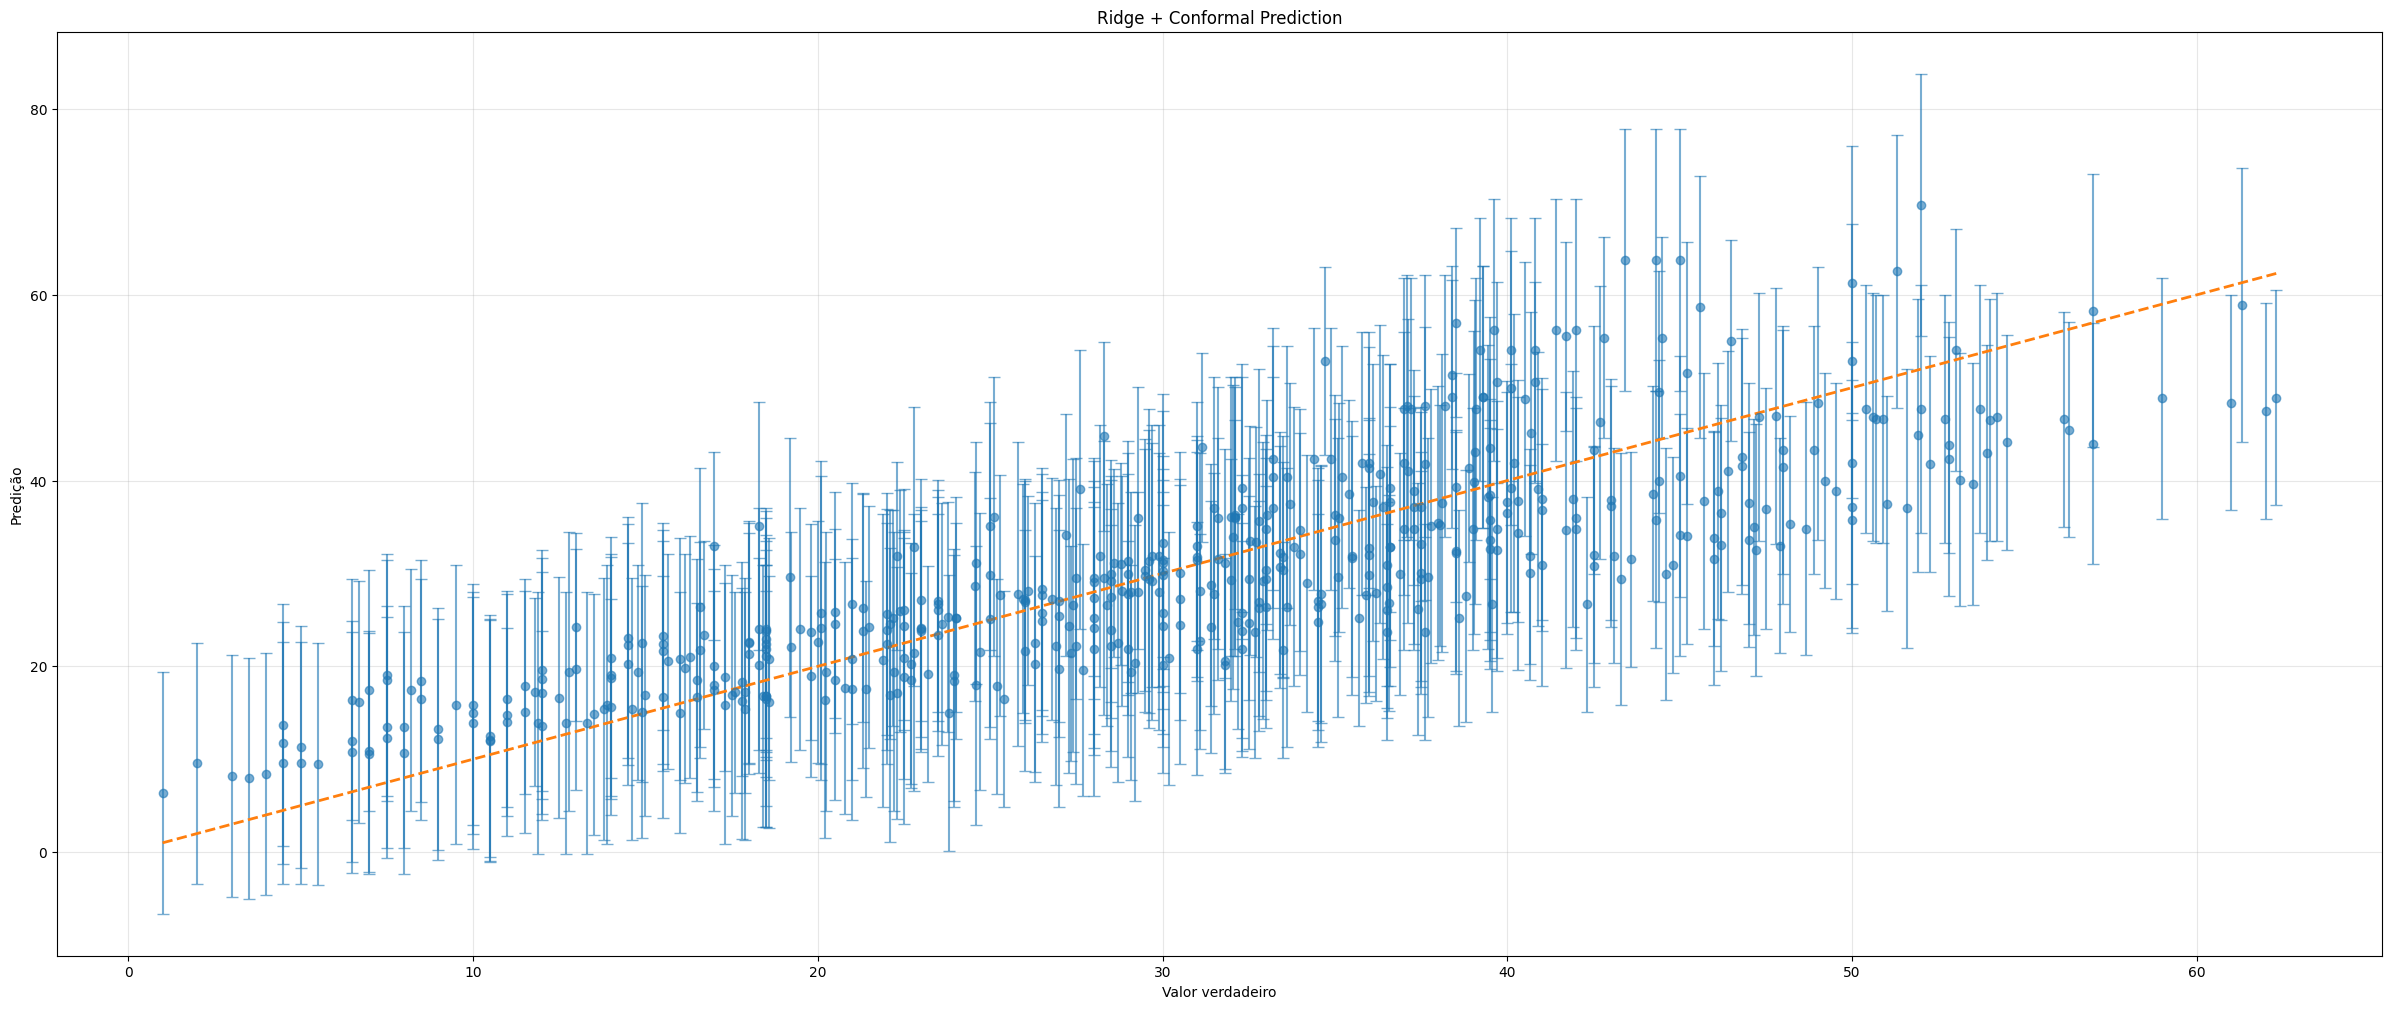

In [ ]:
plot_df = ridge_results.sort_values("y_true")

plt.figure(figsize=(30, 12))

plt.errorbar(
    plot_df["y_true"],
    plot_df["y_pred"],
    yerr=[
        plot_df["y_pred"] - plot_df["lower"],
        plot_df["upper"] - plot_df["y_pred"]
    ],
    fmt="o",
    alpha=0.6,
    capsize=4
)

plt.plot(
    [plot_df["y_true"].min(), plot_df["y_true"].max()],
    [plot_df["y_true"].min(), plot_df["y_true"].max()],
    "--",
    linewidth=2
)

plt.xlabel("Valor verdadeiro")
plt.ylabel("Predição")
plt.title("Ridge + Conformal Prediction")
plt.grid(alpha=0.3)

plt.show()

## Observado vs Predito

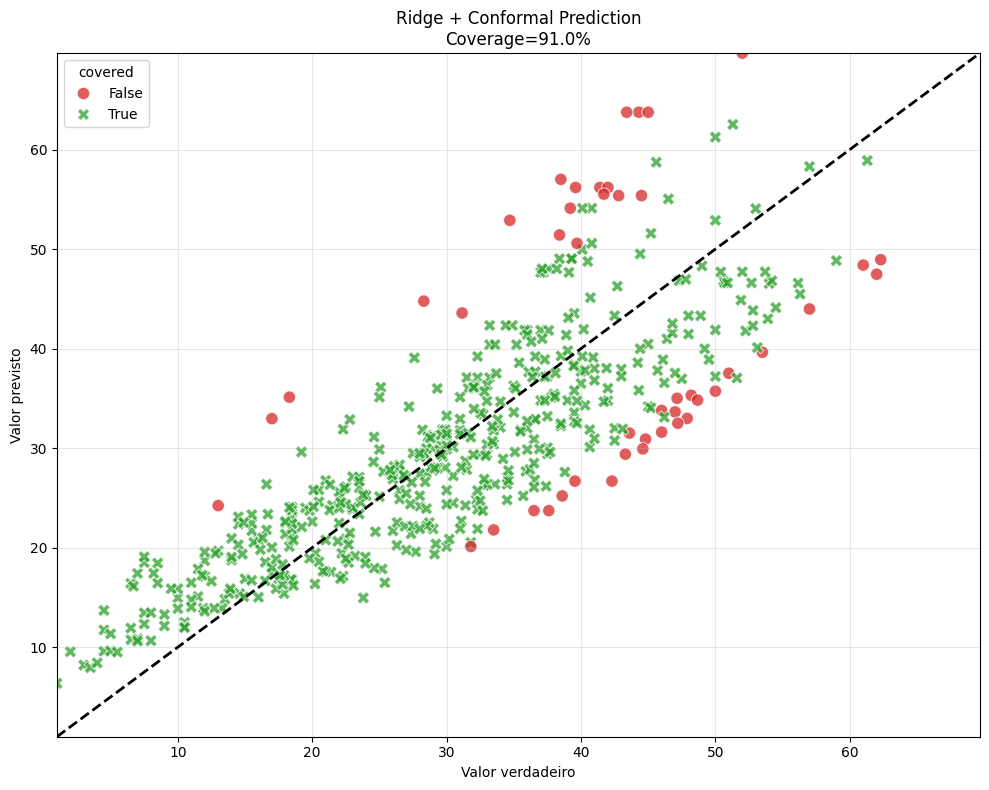

In [ ]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=ridge_results,
    x="y_true",
    y="y_pred",
    hue="covered",
    style="covered",
    palette={
        True: "#2ca02c",
        False: "#d62728"
    },
    s=80,
    alpha=0.75
)

lims = [
    min(
        ridge_results["y_true"].min(),
        ridge_results["y_pred"].min()
    ),
    max(
        ridge_results["y_true"].max(),
        ridge_results["y_pred"].max()
    )
]

plt.plot(
    lims,
    lims,
    "--",
    linewidth=2,
    color="black",
    label="Predição perfeita"
)

plt.xlim(lims)
plt.ylim(lims)

plt.title(
    f"Ridge + Conformal Prediction\nCoverage={coverage:.1%}"
)

plt.xlabel("Valor verdadeiro")
plt.ylabel("Valor previsto")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

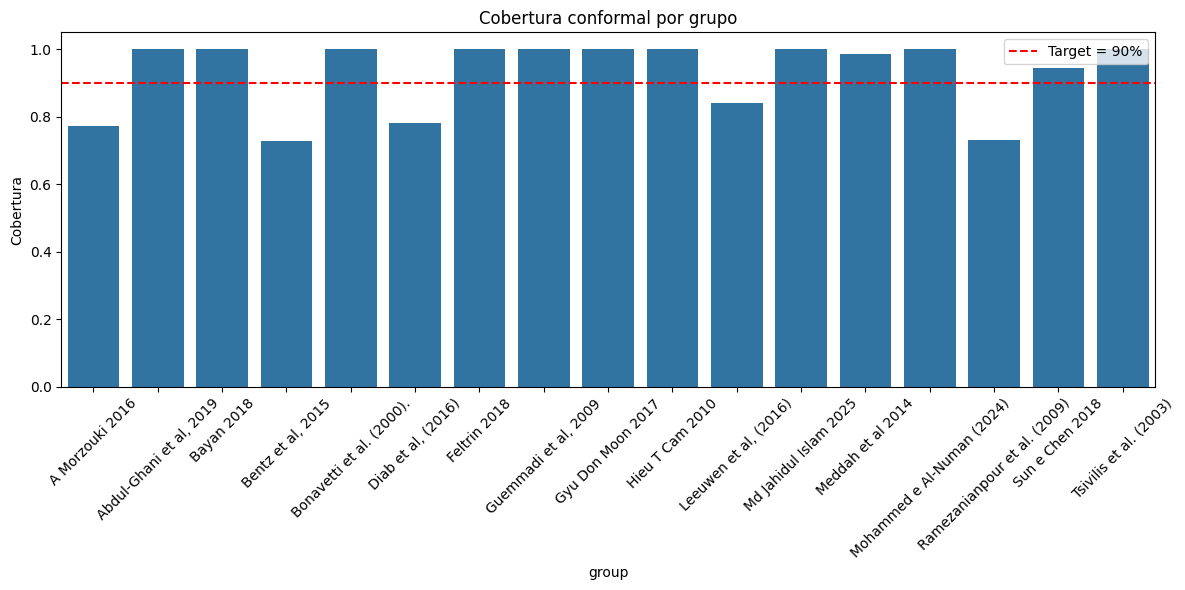

In [ ]:
fold_summary = (
    ridge_results
    .groupby("group")
    .agg(
        coverage=("covered", "mean"),
        width=("interval_width", "mean"),
        mae=("abs_error", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=fold_summary,
    x="group",
    y="coverage"
)

plt.axhline(
    0.90,
    color="red",
    linestyle="--",
    label="Target = 90%"
)

plt.xticks(rotation=45)
plt.ylabel("Cobertura")
plt.title("Cobertura conformal por grupo")
plt.legend()

plt.tight_layout()
plt.show()

## Distribuição dos residuos

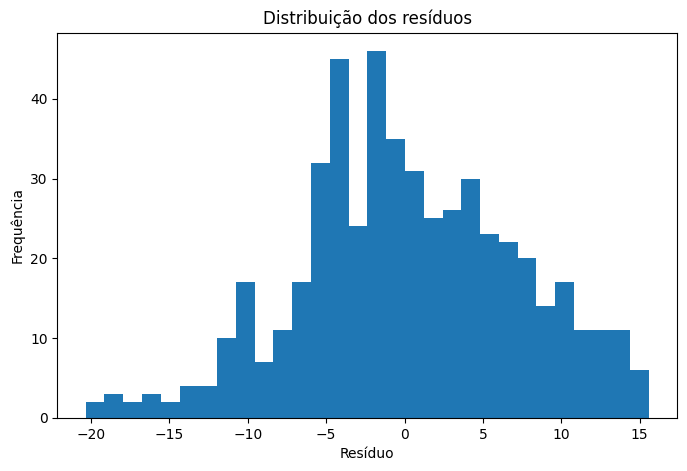

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    ridge_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

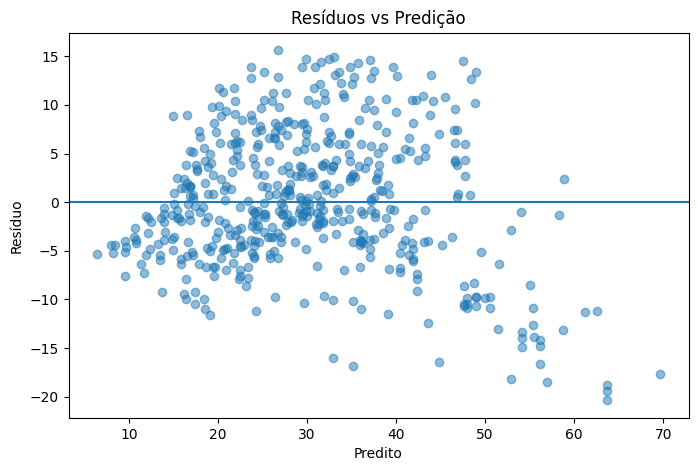

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    ridge_results["y_pred"],
    ridge_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

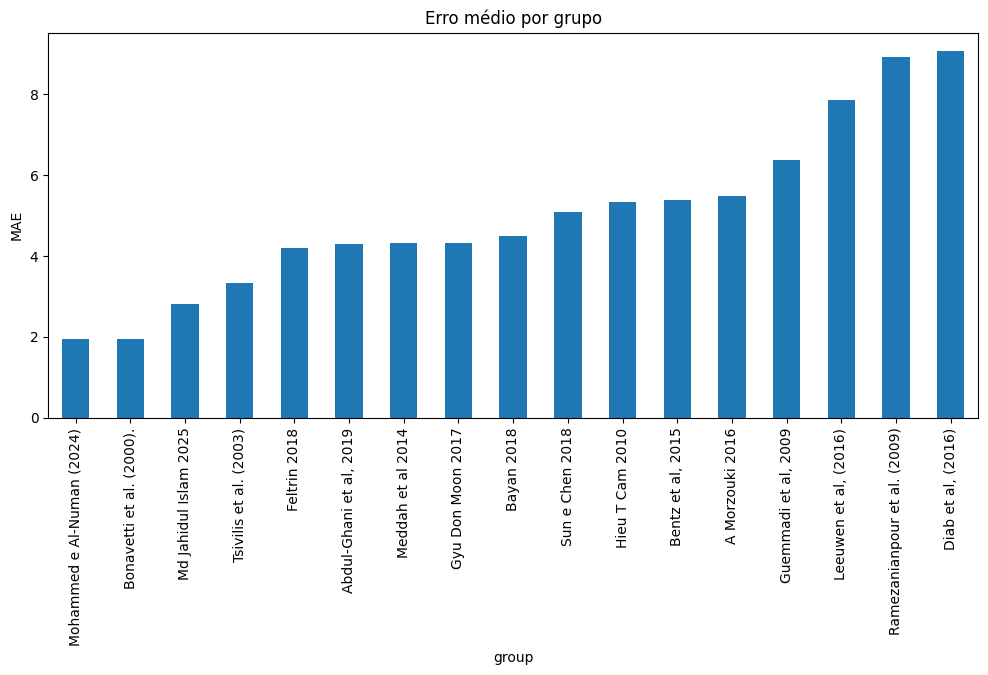

In [ ]:
group_errors = (
    ridge_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [ ]:
top_erros = (
    ridge_results
    .query("abs_error > 15")
    .sort_values("abs_error", ascending=False)
)

print(top_erros.index.tolist())

[221, 216, 226, 266, 265, 211, 442, 231, 264, 263, 186]


In [ ]:
r2 = r2_score(ridge_results["y_true"], ridge_results["y_pred"])
rmse = root_mean_squared_error(ridge_results["y_true"], ridge_results["y_pred"])
mae = mean_absolute_error(ridge_results["y_true"], ridge_results["y_pred"])
mape = mean_absolute_percentage_error(ridge_results["y_true"], ridge_results["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.0243
mean_absolute_error: 5.6305
mean_absolute_percentage_error: 0.2468
R² Score: 69.1321


In [ ]:
for col in X.columns:
    print(col)

    print(
        df_final.iloc[top_erros.index.to_numpy()][col].describe()
    )

    print(df_final.iloc[~top_erros.index.to_numpy()][col].describe())

fib_estimativa_base
count    11.000000
mean      1.252487
std       0.546465
min       0.329526
25%       0.944124
50%       1.267623
75%       1.531745
max       2.151942
Name: fib_estimativa_base, dtype: float64
count    11.000000
mean      0.969032
std       0.272199
min       0.606314
25%       0.790893
50%       0.947214
75%       1.069488
max       1.502911
Name: fib_estimativa_base, dtype: float64
idade_fator_agua
count    11.000000
mean      5.421726
std       2.494567
min       1.339771
25%       4.232239
50%       5.048795
75%       6.677633
max      10.063380
Name: idade_fator_agua, dtype: float64
count    11.000000
mean      4.102752
std       2.821750
min       0.000000
25%       2.495714
50%       3.474839
75%       5.399406
max      10.350696
Name: idade_fator_agua, dtype: float64
pow_interacao_tempo
count    11.000000
mean      1.071170
std       0.608395
min       0.228263
25%       0.714092
50%       1.100996
75%       1.396224
max       2.065279
Name: pow_interacao_t

In [ ]:
top_erros[
    [
        "group",
        "y_true",
        "y_pred",
        "error",
        "abs_error",
        "lower",
        "upper",
        "covered",
        "Relacao_Agua_Cimento",
        "Relacao_Agua_Aglomerante",
        "idade_fator_agua",
        "fib_estimativa_base"
    ]
].head(20)

,group,y_true,y_pred,error,abs_error,lower,upper,covered,Relacao_Agua_Cimento,Relacao_Agua_Aglomerante,idade_fator_agua,fib_estimativa_base
221,"Leeuwen et al, (2016)",43.4,63.750003,-20.350003,20.350003,49.637038,77.862967,False,0.44,0.40,10.226841,1.979958
216,"Leeuwen et al, (2016)",44.3,63.750003,-19.450003,19.450003,49.637038,77.862967,False,0.44,0.40,10.226841,1.979958
226,"Leeuwen et al, (2016)",45.0,63.750003,-18.750003,18.750003,49.637038,77.862967,False,0.44,0.40,10.226841,1.979958
266,A Morzouki 2016,38.5,57.000765,-18.500765,18.500765,46.852330,67.149200,False,0.57,0.54,9.110451,1.578969
265,A Morzouki 2016,34.7,52.890016,-18.190016,18.190016,42.741582,63.038451,False,0.57,0.54,7.894404,1.483928
211,"Leeuwen et al, (2016)",52.0,69.687755,-17.687755,17.687755,55.574791,83.800720,False,0.40,0.40,11.249525,2.233799
442,Sun e Chen 2018,18.3,35.119691,-16.819691,16.819691,21.754960,48.484421,False,0.59,0.45,5.647805,1.194915
231,"Leeuwen et al, (2016)",39.6,56.190010,-16.590010,16.590010,42.077045,70.302974,False,0.50,0.40,8.999620,1.675349
264,A Morzouki 2016,28.3,44.771581,-16.471581,16.471581,34.623146,54.920016,False,0.57,0.54,5.845974,1.254386
263,A Morzouki 2016,17.0,32.961360,-15.961360,15.961360,22.812925,43.109794,False,0.57,0.54,3.413877,0.857826
